<a href="https://colab.research.google.com/github/aditisri712/Netflix-data-analysis/blob/main/netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel


In [3]:
df = pd.read_csv('netflix_titles.csv')
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns.")
df.head()

Dataset loaded with 5398 rows and 12 columns.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020.0,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021.0,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021.0,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


/tmp/ipykernel_10167/2313546900.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df, palette='viridis')


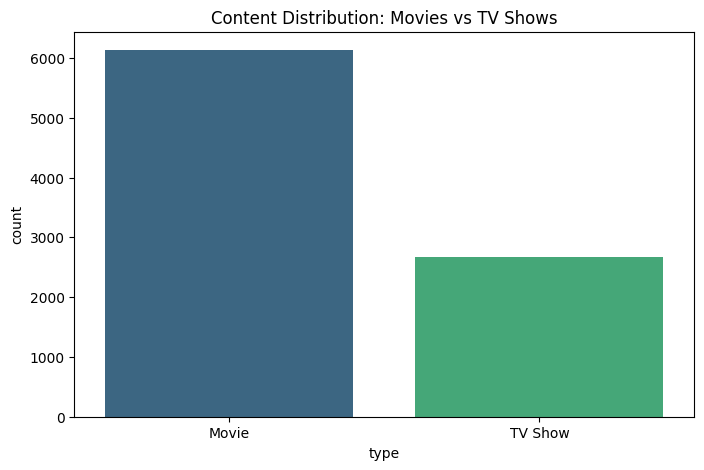

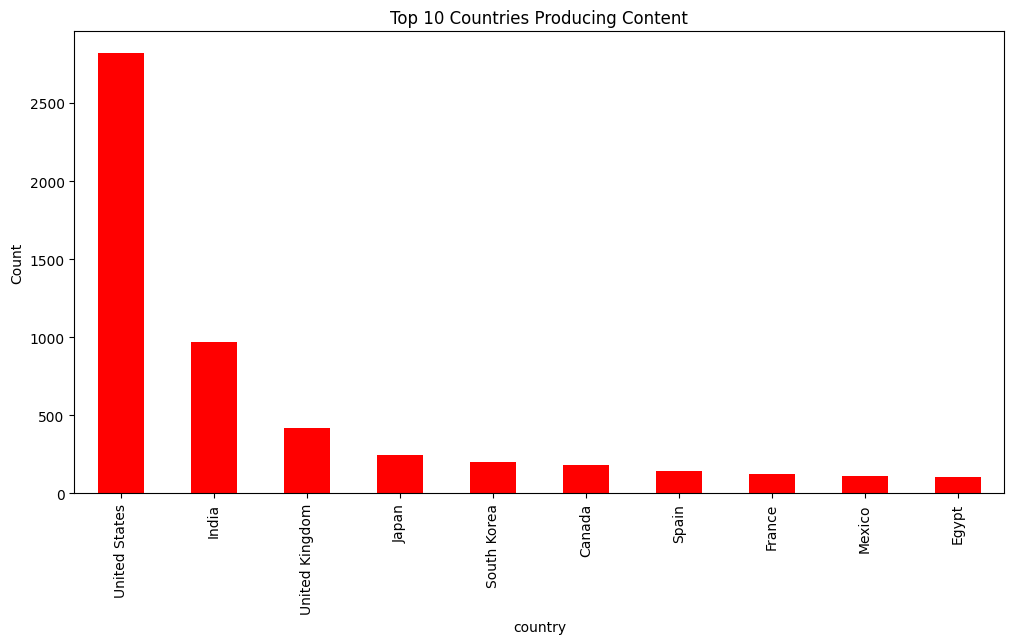

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', data=df, palette='viridis')
plt.title('Content Distribution: Movies vs TV Shows')
plt.show()

plt.figure(figsize=(12, 6))
df['country'].value_counts().head(10).plot(kind='bar', color='Red')
plt.title('Top 10 Countries Producing Content')
plt.ylabel('Count')
plt.show()

In [ ]:
df['description'] = df['description'].fillna('')

tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

def get_recommendations(title, cosine_sim=cosine_sim):
    try:
        idx = df.index[df['title'].str.lower() == title.lower()].tolist()[0]
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:6] # Top 5 similar titles
        movie_indices = [i[0] for i in sim_scores]
        return df[['title', 'type', 'listed_in']].iloc[movie_indices]
    except IndexError:
        return "Title not found in dataset."

get_recommendations('Blood & Water')

,title,type,listed_in
5344,Message from the King,Movie,"Independent Movies, Thrillers"
1884,Walk Away from Love,Movie,"Dramas, Romantic Movies"
4285,Lilli,Movie,"Dramas, Independent Movies, International Movies"
4271,Lion Pride,TV Show,"International TV Shows, Romantic TV Shows, TV ..."
4209,Next Enti?,Movie,"Comedies, Dramas, International Movies"


/tmp/ipykernel_10167/749079059.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='month_added', data=df, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='coolwarm')


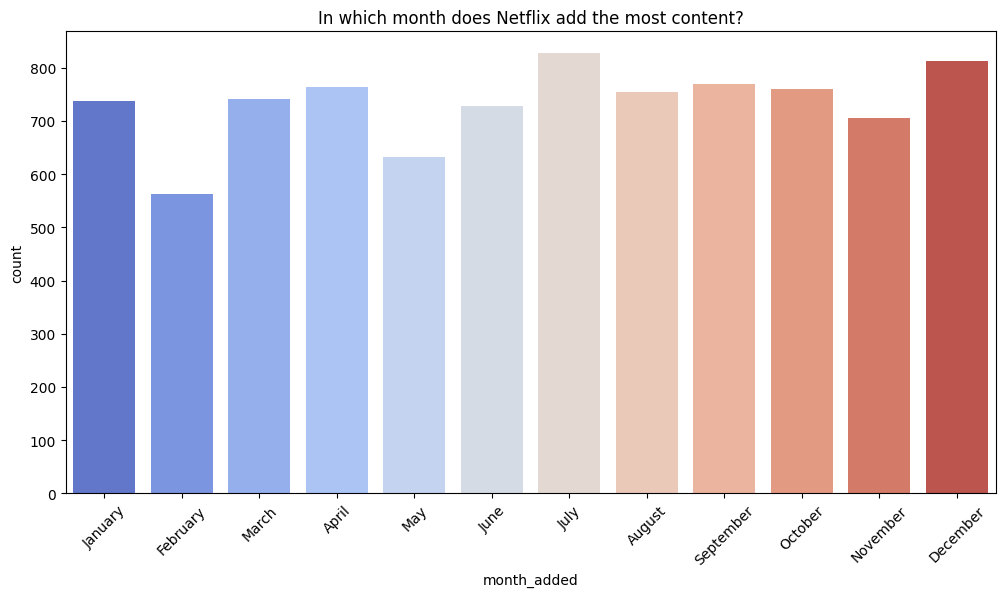

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['month_added'] = df['date_added'].dt.month_name()

plt.figure(figsize=(12, 6))
sns.countplot(x='month_added', data=df, order=['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], palette='coolwarm')
plt.xticks(rotation=45)
plt.title('In which month does Netflix add the most content?')
plt.show()

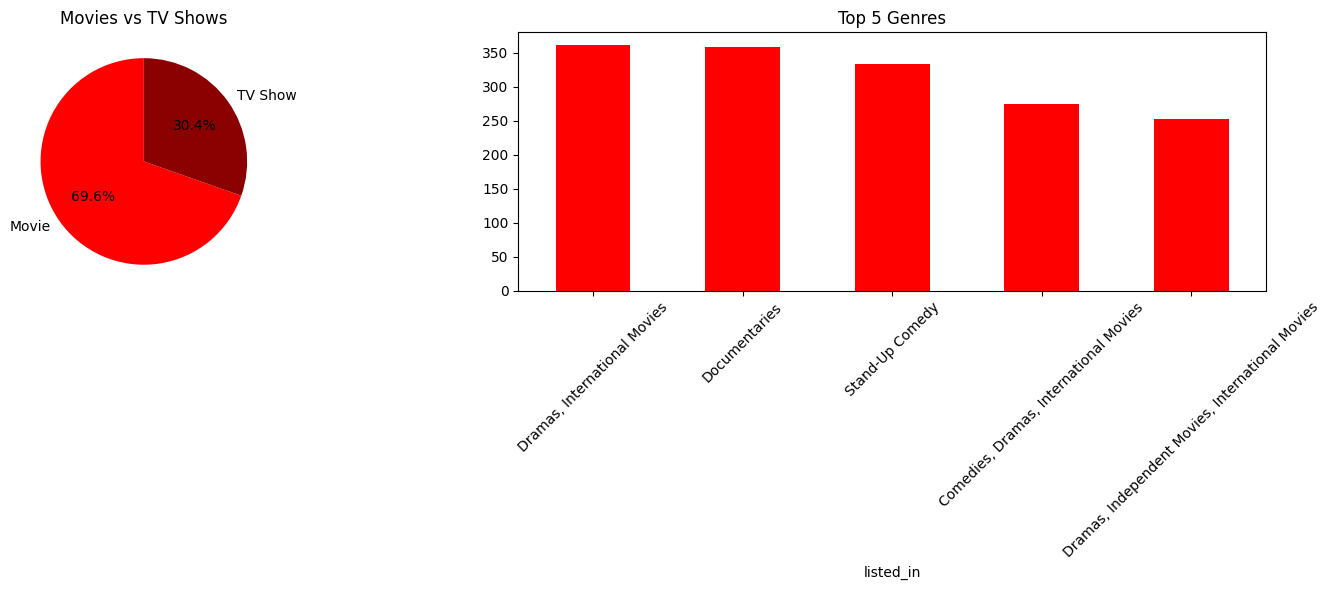

Recommendations for 'Blood & Water':
5344    Message from the King
1884      Walk Away from Love
4285                    Lilli
4271               Lion Pride
4209               Next Enti?
Name: title, dtype: object


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

df = pd.read_csv('netflix_titles.csv')
df['description'] = df['description'].fillna('')

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', colors=['#ff0000', '#8b0000'], startangle=90)
plt.title('Movies vs TV Shows')

plt.subplot(1, 2, 2)
top_genres = df['listed_in'].value_counts().head(5)
top_genres.plot(kind='bar', color='red')
plt.title('Top 5 Genres')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['description'])
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

def recommend(movie_name):
    try:
        idx = df[df['title'].str.lower() == movie_name.lower()].index[0]
        scores = list(enumerate(cosine_sim[idx]))
        scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]
        movie_indices = [i[0] for i in scores]
        return df['title'].iloc[movie_indices]
    except:
        return "Movie not found!"
print("Recommendations for 'Blood & Water':")
print(recommend('Blood & Water'))